# 5G/UAS co-simulation

A PX4 drone flies a waypoint mission in Gazebo. The measured pose drives a Simu5G
5G network, and a bridge joins the two into a 44 column cyber incident dataset.

There are eight runs. One is benign, one is suspicious, and the other six are one
for each attack class. Every run flies its own mission, so the flights can be
compared before anything is read into the telemetry.

Sections 1 to 3 run the experiment. Sections 4 and 5 report on it.

## 1. Path setup

In [1]:
import os
import signal
import subprocess
import sys
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
PROJECT = HERE.parent
PX4_RUNTIME = PROJECT / "UGV_UAV/px4_runtime"
SHARED_MODELS = PROJECT / "simulation/models"

WORLD_NAME = "baylands_editable"
WORLD_FILE = HERE / "worlds/baylands_uav.world"
UAV_MODEL = "gz_x500_mapping"
SPAWN = {"x": 211.12966918945318, "y": -256.3474426269531, "z": 2.935702896118163}

BENIGN = "B1_BENIGN_001"
SCENARIOS = ["S1_ANOMALY_001", "M1_DOS_001", "M2_SESSION_001", "M3_IDENTITY_001",
             "M4_CONTROL_001", "M5_LATERAL_001", "M6_API_001"]
RUNS = [BENIGN] + SCENARIOS
FINAL = HERE / "data/drone_network_telemetry_cosim.csv"

MISSION = ("telemetry-session", "command-session")   # the drone's own flows
WINDOW = (40, 80)                                    # the label window, seconds


# Run one step and stop the whole pipeline if it fails.
def step(title, command):
    print(f"\n {title} ", flush=True)
    result = subprocess.run([sys.executable] + command, cwd=HERE)
    if result.returncode:
        raise SystemExit(f"[FAILED] {title.strip()}")


# Read an exported pose trace: time, east, north, up.
def pose(run):
    lines = (HERE / "trace" / f"{run}_pose.txt").read_text().splitlines()[1:]
    return np.array([[float(v) for v in l.split()] for l in lines])


# Read a per-run dataset and add the mission second each window starts at.
def dataset(run):
    d = pd.read_csv(HERE / f"data/{run}_cosim.csv")
    stamp = pd.to_datetime(d.timestamp)
    d["second"] = (stamp - stamp.min()).dt.total_seconds().astype(int)
    return d

## 2. Simulator check

This starts Gazebo and PX4 SITL only. Nothing is recorded. The window opens
paused.

In [2]:
# Read the mission markers straight from the world. Returns NED offsets from spawn.
def read_route():
    world = ET.parse(WORLD_FILE).getroot().find("world")
    markers = {}
    for entity in world:
        name = entity.get("name") or entity.findtext("name")
        pose = (entity.findtext("pose") or "").split()
        if name in ("goal",) or (name or "").startswith("waypoint"):
            x, y, z = (float(value) for value in pose[:3])
            markers[name] = (y - SPAWN["y"], x - SPAWN["x"], SPAWN["z"] - z)
    order = sorted(n for n in markers if n.startswith("waypoint")) + ["goal"]
    return [(name, *markers[name]) for name in order if name in markers]


def gazebo_already_running():
    """A second Gazebo server would fight the first for the same world."""
    try:
        probe = subprocess.run(["gz", "service", "-l"], capture_output=True,
                               text=True, timeout=10)
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False
    return probe.returncode == 0 and "/server_control" in probe.stdout


def simulation_environment():
    env = os.environ.copy()
    env["QT_QPA_PLATFORM"] = env.get("QT_QPA_PLATFORM", "xcb")
    env["GZ_SIM_RESOURCE_PATH"] = ":".join(filter(None, [
        str(SHARED_MODELS), str(PX4_RUNTIME / "models"),
        env.get("GZ_SIM_RESOURCE_PATH", "")]))
    env["GZ_SIM_SYSTEM_PLUGIN_PATH"] = ":".join(filter(None, [
        str(PX4_RUNTIME / "plugins"), env.get("GZ_SIM_SYSTEM_PLUGIN_PATH", "")]))
    return env


def stop(process):
    """Signal the whole process group; Gazebo and PX4 both spawn children."""
    if process is None or process.poll() is not None:
        return
    os.killpg(process.pid, signal.SIGINT)
    try:
        process.wait(timeout=15)
    except subprocess.TimeoutExpired:
        os.killpg(process.pid, signal.SIGTERM)

In [3]:
# Start Gazebo and PX4 SITL. Returns both processes; the caller stops them.
def start_gazebo_and_px4():
    world = WORLD_FILE.resolve()
    if not world.is_file():
        raise FileNotFoundError(f"World is missing: {world}")
    px4_binary = PX4_RUNTIME / "bin/px4"
    if not px4_binary.is_file() or not (PX4_RUNTIME / "rootfs").is_dir():
        raise FileNotFoundError(f"PX4 runtime is missing: {PX4_RUNTIME}")

    env = simulation_environment()
    gazebo = subprocess.Popen(["gz", "sim", str(world)], cwd=HERE, env=env,
                              stdin=subprocess.DEVNULL, start_new_session=True)
    print(f"[WORLD] {world.name}", flush=True)
    time.sleep(6)
    if gazebo.poll() is not None:
        raise RuntimeError("Gazebo exited during startup")

    px4_env = env.copy()
    px4_env.update({
        "PX4_SYS_AUTOSTART": "4001",
        "PX4_SIM_MODEL": UAV_MODEL,
        "PX4_GZ_STANDALONE": "1",
        "PX4_GZ_NO_FOLLOW": "1",
        "PX4_GZ_WORLD": WORLD_NAME,
        "PX4_GZ_MODEL_POSE": f"{SPAWN['x']},{SPAWN['y']},{SPAWN['z']}",
        "HEADLESS": "0",
    })
    px4 = subprocess.Popen([str(px4_binary), "-d"], cwd=PX4_RUNTIME / "rootfs",
                           env=px4_env, stdin=subprocess.PIPE, start_new_session=True)
    print(f"[UAV] spawn x={SPAWN['x']:.1f} y={SPAWN['y']:.1f} z={SPAWN['z']:.1f}", flush=True)
    time.sleep(8)
    if px4.poll() is not None:
        raise RuntimeError("PX4 exited during startup")
    return gazebo, px4, env

In [ ]:
if gazebo_already_running():
    raise SystemExit("A Gazebo server is already running. Close it first.")

gazebo, px4, env = start_gazebo_and_px4()

route = read_route()
print(f"[ROUTE] {', '.join(name for name, *_ in route)}")
print("[READY] Gazebo and PX4 are running with no recordings.")

[WORLD] baylands_uav.world


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L219]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L233]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L259]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warn

[UAV] spawn x=211.1 y=-256.3 z=2.9

______  __   __    ___ 
| ___ \ \ \ / /   /   |
| |_/ /  \ V /   / /| |
|  __/   /   \  / /_| |
| |     / /^\ \ \___  |
\_|     \/   \/     |_/

px4 starting.

INFO  [px4] startup script: /bin/sh etc/init.d-posix/rcS 0
env SYS_AUTOSTART: 4001
INFO  [param] selected parameter default file parameters.bson
INFO  [param] importing from 'parameters.bson'
INFO  [parameters] BSON document size 759 bytes, decoded 759 bytes (INT32:19, FLOAT:17)
INFO  [param] selected parameter backup file parameters_backup.bson
INFO  [dataman] data manager file './dataman' size is 1208528 bytes
INFO  [init] Gazebo simulator 8.11.0
INFO  [init] Standalone PX4 launch, waiting for Gazebo
INFO  [init] Waiting for Gazebo world...


libEGL warning: pci id for fd 70: 10de:2191, driver (null)

pci id for fd 71: 10de:2191, driver (null)
pci id for fd 72: 10de:2191, driver (null)
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 70: 10de:2191, driver (null)

pci id for fd 71: 10de:2191, driver (null)
pci id for fd 72: 10de:2191, driver (null)
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 70: 10de:2191, driver (null)



INFO  [init] Gazebo world is ready
INFO  [init] Gazebo model pose: 211.12966918945318 -256.3474426269531 2.935702896118163 0 0 0
INFO  [init] Spawning Gazebo model


...

INFO  [gz_bridge] world: baylands_editable, model: x500_mapping_0
INFO  [commander] LED: open /dev/led0 failed (22)


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L219]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L233]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L259]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warn

INFO  [vision_target_estimator] VTE for static target init
INFO  [uxrce_dds_client] init UDP agent IP:127.0.0.1, port:8888
INFO  [mavlink] mode: Normal, data rate: 4000000 B/s on udp port 18570 remote port 14550
INFO  [mavlink] mode: Onboard, data rate: 4000000 B/s on udp port 14580 remote port 14540
INFO  [mavlink] mode: Onboard, data rate: 4000 B/s on udp port 14280 remote port 14030
INFO  [mavlink] mode: Gimbal, data rate: 400000 B/s on udp port 13030 remote port 13280
INFO  [logger] logger started (mode=all)
INFO  [logger] Max log file size: 1024 MiB
INFO  [logger] Start file log (type: full)
INFO  [logger] [logger] ./log/2026-09-03/15_13_12.ulg	
INFO  [logger] Opened full log file: ./log/2026-09-03/15_13_12.ulg
INFO  [mavlink] MAVLink only on localhost (set param MAV_{i}_BROADCAST = 1 to enable network)
INFO  [mavlink] MAVLink only on localhost (set param MAV_{i}_BROADCAST = 1 to enable network)
INFO  [px4] Startup script returned successfully


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:<data-string>:L232]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:<data-string>:L254]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:<data-string>:L301]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="navsat_sensor"]/gz_frame_id:<data-string>:L307]: XML Element[gz_frame_id], child of element[sensor], n

INFO  [lockstep_scheduler] setting initial absolute time to 1000 us
INFO  [tone_alarm] home set
WARN  [health_and_arming_checks] Preflight Fail: no heading reference
WARN  [health_and_arming_checks] Preflight Fail: No connection to the GCS
WARN  [health_and_arming_checks] Preflight Fail: no heading reference
WARN  [health_and_arming_checks] Preflight Fail: No connection to the GCS


In [5]:
stop(px4)
stop(gazebo)
print("[SHUTDOWN] Gazebo and PX4 stopped.")


PX4 Exiting...
Exiting NOW.
[SHUTDOWN] Gazebo and PX4 stopped.


## 3. Run the experiment

This is the part that takes time, about 35 minutes of flying and 15 minutes of
network simulation.

### 3.1 Fly and record one mission per scenario

Gazebo opens paused for each run. Press play in the window and the mission
starts. The bag only begins recording once physics is running and the topic rates
have been measured, so it holds the flight and nothing else.

Any run that is already recorded is skipped. There are eight runs, so eight play
clicks.

In [6]:
for run in RUNS:
    if (HERE / "logs" / run / "rosbag/metadata.yaml").is_file():
        print(f"\n***** {run} already recorded *****")
        continue
    print(f"\n***** {run} *****")
    step(f"Record {run}", ["record_mission.py", "--run-id", run])
    time.sleep(5)


***** B1_BENIGN_001 *****

 Record B1_BENIGN_001 
[WORLD] baylands_uav.world


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L219]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L233]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L259]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warn

[UAV] spawn x=211.1 y=-256.3 z=2.9

______  __   __    ___ 
| ___ \ \ \ / /   /   |
| |_/ /  \ V /   / /| |
|  __/   /   \  / /_| |
| |     / /^\ \ \___  |
\_|     \/   \/     |_/

px4 starting.

INFO  [px4] startup script: /bin/sh etc/init.d-posix/rcS 0
env SYS_AUTOSTART: 4001
INFO  [param] selected parameter default file parameters.bson
INFO  [param] importing from 'parameters.bson'
INFO  [parameters] BSON document size 759 bytes, decoded 759 bytes (INT32:19, FLOAT:17)
INFO  [param] selected parameter backup file parameters_backup.bson
INFO  [dataman] data manager file './dataman' size is 1208528 bytes
INFO  [init] Gazebo simulator 8.11.0
INFO  [init] Standalone PX4 launch, waiting for Gazebo
INFO  [init] Waiting for Gazebo world...


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:<data-string>:L232]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:<data-string>:L254]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:<data-string>:L301]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="navsat_sensor"]/gz_frame_id:<data-string>:L306]: XML Element[gz_frame_id], child of element[sensor], n

INFO  [init] Gazebo world is ready
INFO  [init] Gazebo model pose: 211.12966918945318 -256.3474426269531 2.935702896118163 0 0 0
INFO  [init] Spawning Gazebo model
[ROUTE] waypoint_1, waypoint_2, waypoint_3, goal
[WAITING] press play in the Gazebo window
INFO  [gz_bridge] world: baylands_editable, model: x500_mapping_0
INFO  [commander] LED: open /dev/led0 failed (22)


...

INFO  [init] Gazebo world is ready
INFO  [init] Gazebo model pose: 211.12966918945318 -256.3474426269531 2.935702896118163 0 0 0
INFO  [init] Spawning Gazebo model
[ROUTE] waypoint_1, waypoint_2, waypoint_3, goal
[WAITING] press play in the Gazebo window
INFO  [gz_bridge] world: baylands_editable, model: x500_mapping_0
INFO  [commander] LED: open /dev/led0 failed (22)


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L219]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L233]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_base"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:/home/basudeo/Documents/EiraX/simulation/models/x500_mapping_base/model.sdf:L259]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warn

INFO  [vision_target_estimator] VTE for static target init
INFO  [uxrce_dds_client] init UDP agent IP:127.0.0.1, port:8888
INFO  [mavlink] mode: Normal, data rate: 4000000 B/s on udp port 18570 remote port 14550
INFO  [mavlink] mode: Onboard, data rate: 4000000 B/s on udp port 14580 remote port 14540
INFO  [mavlink] mode: Onboard, data rate: 4000 B/s on udp port 14280 remote port 14030
INFO  [mavlink] mode: Gimbal, data rate: 400000 B/s on udp port 13030 remote port 13280
INFO  [logger] logger started (mode=all)
INFO  [logger] Max log file size: 1024 MiB
INFO  [logger] Start file log (type: full)
INFO  [logger] [logger] ./log/2026-09-03/15_42_02.ulg	
INFO  [logger] Opened full log file: ./log/2026-09-03/15_42_02.ulg
INFO  [mavlink] MAVLink only on localhost (set param MAV_{i}_BROADCAST = 1 to enable network)
INFO  [mavlink] MAVLink only on localhost (set param MAV_{i}_BROADCAST = 1 to enable network)
INFO  [px4] Startup script returned successfully


Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="air_pressure_sensor"]/gz_frame_id:<data-string>:L232]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="magnetometer_sensor"]/gz_frame_id:<data-string>:L254]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="imu_sensor"]/gz_frame_id:<data-string>:L301]: XML Element[gz_frame_id], child of element[sensor], not defined in SDF. Copying[gz_frame_id] as children of [sensor].
Warning [Utils.cc:132] [/sdf/model[@name="x500_mapping_0"]/link[@name="base_link"]/sensor[@name="navsat_sensor"]/gz_frame_id:<data-string>:L307]: XML Element[gz_frame_id], child of element[sensor], n

INFO  [lockstep_scheduler] setting initial absolute time to 1000 us
[PLAYING] physics is running
INFO  [tone_alarm] home set
WARN  [health_and_arming_checks] Preflight Fail: no heading reference
WARN  [health_and_arming_checks] Preflight Fail: No connection to the GCS
INFO  [mavlink] partner IP: 127.0.0.1
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
[MAVROS] publishing 3 topics
[TOPIC RATES]
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
WARN  [commander] command 520 unsupported
INFO  [tone_alarm] notify negative
WARN  [health_and_arming_checks] Preflight Fail: no heading reference
WARN  [health_and_arming_checks] Preflight Fail: No connection to the GCS
WARN  [commander] command 520 unsupported
IN

### 3.2 One scenario at a time, validated after each

Simu5G builds the network from the pose trace and the measured topic rates. The
bridge joins them, and the validator checks the 44 column contract. One attack
class per run, never combined.

In [7]:
for run in RUNS:
    print(f"\n***** {run} *****")
    step(f"Simu5G scenario {run}", ["run_scenario.py", "--run-id", run])
    step(f"Bridge {run}", [
        "sim/bridge/assemble.py", "--window", "1.0",
        "--ros-log", f"logs/{run}",
        "--net-csv", f"logs/{run}_net.csv",
        "--manifest", f"manifests/{run}.yaml",
        "--out", f"data/{run}_cosim.csv"])
    step(f"Validate {run}",
         ["validate_dataset.py", f"data/{run}_cosim.csv", "schema_reference.json"])


***** B1_BENIGN_001 *****

 Simu5G scenario B1_BENIGN_001 
[SCENARIO] 1 UAV, 1 gNB, 5G core, edge node, mission backend
[MOBILITY] 6618 points over 1 recorded flight(s)
[FLOWS] telemetry, command
[SIMU5G] running 135s, this takes a few minutes
[EXPORTED] logs/B1_BENIGN_001_net.csv (8787 rows)

 Bridge B1_BENIGN_001 
ASSEMBLED: data/B1_BENIGN_001_cosim.csv (270 rows, 44 columns)

 Validate B1_BENIGN_001 
RESULT: PASSED (270 rows, 44 columns)

***** S1_ANOMALY_001 *****

 Simu5G scenario S1_ANOMALY_001 
[SCENARIO] 1 UAV, 1 gNB, 5G core, edge node, mission backend
[MOBILITY] 6727 points over 1 recorded flight(s)
[FLOWS] telemetry, command, ambiguous_logins
[SIMU5G] running 135s, this takes a few minutes
[EXPORTED] logs/S1_ANOMALY_001_net.csv (9045 rows)

 Bridge S1_ANOMALY_001 
ASSEMBLED: data/S1_ANOMALY_001_cosim.csv (310 rows, 44 columns)

 Validate S1_ANOMALY_001 
RESULT: PASSED (310 rows, 44 columns)

***** M1_DOS_001 *****

 Simu5G scenario M1_DOS_001 
[SCENARIO] 1 UAV, 1 gNB, 5G co

### 3.3 Concatenate, validate, and report the baseline metrics

In [8]:
print("\n***** final dataset *****")
step("Concatenate the final dataset",
     ["sim/bridge/concat.py"] + [f"data/{run}_cosim.csv" for run in RUNS]
     + ["--out", str(FINAL.relative_to(HERE))])
step("Validate the final dataset",
     ["validate_dataset.py", str(FINAL.relative_to(HERE)), "schema_reference.json"])
step("Baseline metrics", ["baseline_model.py"])

print(f"\n***** complete: {FINAL.relative_to(HERE)} over {len(RUNS)} runs *****")


***** final dataset *****

 Concatenate the final dataset 
CONCATENATED: data/drone_network_telemetry_cosim.csv (2440 rows, 44 columns, 8 runs)

 Validate the final dataset 
RESULT: PASSED (2440 rows, 44 columns)

 Baseline metrics 
[CO-SIMULATION] rows=2440 accuracy=0.9740 macro-F1=0.9305
[SYNTHETIC] rows=10000 accuracy=0.9990 macro-F1=0.9989
[WROTE] reports/model_metrics.md

***** complete: data/drone_network_telemetry_cosim.csv over 8 runs *****


## 4. Flight comparison

The attacks are injected in Simu5G after the flight is already recorded, so no
attack can change a trajectory. Any difference between the eight flights is the
simulator repeating itself imperfectly, and that sets the noise floor a telemetry
difference has to clear.

Most of the difference comes from the flights starting at slightly different
moments rather than following different paths. Each run is also compared after
shifting it in time to fit the benign run as closely as it can, and what is left
is the geometry the runs actually disagree on.

In [9]:
traces = {run: pose(run) for run in RUNS}
reference = traces[BENIGN]
t = reference[:, 0]
airborne = reference[:, 3] > 1.0
short = lambda run: run.split("_")[1] if "_" in run else run
SHIFTS = np.arange(-3.0, 3.001, 0.01)


def at(d, offset=0.0):
    """Where run d was at each of the benign run's timestamps."""
    return np.stack([np.interp(t + offset, d[:, 0], d[:, i]) for i in (1, 2, 3)], axis=1)


def separation(d, offset=0.0):
    return np.linalg.norm(at(d, offset) - reference[:, 1:4], axis=1)


length = lambda d: np.linalg.norm(np.diff(d[:, 1:4], axis=0), axis=1).sum()
takeoff = {run: d[d[:, 3] > 1.0][0, 0] if (d[:, 3] > 1.0).any() else np.nan
           for run, d in traces.items()}

# The best time shift is the one that minimises separation while airborne.
shift, raw, aligned = {}, {}, {}
for run, d in traces.items():
    raw[run] = separation(d)[airborne].mean()
    if run == BENIGN:
        shift[run], aligned[run] = 0.0, 0.0
        continue
    shift[run] = SHIFTS[np.array([separation(d, s)[airborne].mean() for s in SHIFTS]).argmin()]
    aligned[run] = separation(d, shift[run])[airborne].mean()

print(f"{'run':18s}{'samples':>9s}{'dur s':>8s}{'path m':>9s}{'takeoff s':>11s}"
      f"{'sep m':>8s}{'shift s':>9s}{'aligned m':>11s}")
for run, d in traces.items():
    print(f"{run:18s}{len(d):9d}{d[-1, 0]:8.1f}{length(d):9.1f}{takeoff[run]:11.1f}"
          f"{raw[run]:8.3f}{shift[run]:+9.2f}{aligned[run]:11.3f}")
print(f"\nairborne samples only; benign is the reference, so its own row is zero")


run                 samples   dur s   path m  takeoff s   sep m  shift s  aligned m
B1_BENIGN_001          7117   145.0    354.9        6.5   0.000    +0.00      0.000
S1_ANOMALY_001         7042   141.3    355.0        5.9   2.993    -0.80      1.217
M1_DOS_001             7052   141.2    354.8        6.2   2.787    -0.73      1.361
M2_SESSION_001         7019   140.9    354.4        6.5   1.937    -0.50      1.211
M3_IDENTITY_001        7116   143.6    355.0        6.4   1.191    -0.26      0.969
M4_CONTROL_001         7072   142.4    355.8        6.6   1.188    +0.07      1.156
M5_LATERAL_001         7059   141.7    355.6        6.3   2.156    -0.59      1.118
M6_API_001             7062   141.4    355.0        6.4   2.279    -0.57      1.367

airborne samples only; benign is the reference, so its own row is zero


## 5. What each attack does to the telemetry

Every run is compared against the benign run over the same 40 to 80 second
window. The mission flows are the drone's own telemetry and command traffic,
which is what a detector watches. The injected flow is the attacker's own
traffic, and it is only present in the attack runs.

In [10]:
METRICS = ["latency_ms", "jitter_ms", "packets_per_second", "throughput_kbps"]


def window(d, mission_only=True):
    rows = d.second.between(*WINDOW, inclusive="left")
    if mission_only:
        rows &= d.session_id.isin(MISSION)
    return d[rows]


telemetry = {run: dataset(run) for run in RUNS}
baseline = window(telemetry[BENIGN])[METRICS].mean()

print(f"effect on the mission flows during {WINDOW[0]}-{WINDOW[1]}s, "
      f"with the traffic each attack injected\n")
print(f"{'run':12s}{'injected flow':>24s}{'pps':>8s}{'kbps':>9s}"
      + "".join(f"{'d ' + m.split('_')[0][:8]:>11s}" for m in METRICS))
print(f"{'benign':12s}{'-':>24s}{'-':>8s}{'-':>9s}"
      + "".join(f"{baseline[m]:11.3f}" for m in METRICS))

effect, injected = {}, {}
for run in SCENARIOS:
    effect[run] = window(telemetry[run])[METRICS].mean() - baseline
    rogue = window(telemetry[run], mission_only=False)
    injected[run] = rogue[~rogue.session_id.isin(MISSION)]
    name = injected[run].session_id.iloc[0] if len(injected[run]) else "reuses a mission session"
    pps = injected[run].packets_per_second.mean() if len(injected[run]) else 0.0
    kbps = injected[run].throughput_kbps.mean() if len(injected[run]) else 0.0
    print(f"{short(run):12s}{name:>24s}{pps:8.1f}{kbps:9.1f}"
          + "".join(f"{effect[run][m]:+11.3f}" for m in METRICS))

print("\nthe benign row is absolute; every other row is a delta from it")

effect on the mission flows during 40-80s, with the traffic each attack injected

run                    injected flow     pps     kbps  d latency   d jitter  d packets d throughp
benign                             -       -        -     11.509      0.294     25.450     15.970
ANOMALY         misconfigured-client     2.0      4.1     -0.144     -0.097     +0.050     +0.030
DOS                      rogue-flood   199.0   1910.6     +3.458     +1.391     -0.262     -0.160
SESSION     reuses a mission session     0.0      0.0     +0.696     +0.020     -7.783     -4.236
IDENTITY             stolen-identity     1.0      4.1     -0.524     -0.067     -0.062     -0.038
CONTROL                rogue-command    19.9     20.4     -0.339     +0.353     -0.037     -0.023
LATERAL                        probe     4.0      3.1     -0.148     +0.123     +0.050     +0.030
API                        rogue-api   199.0   1273.8     +3.171     +1.144     +0.012     +0.008

the benign row is absolute; every o

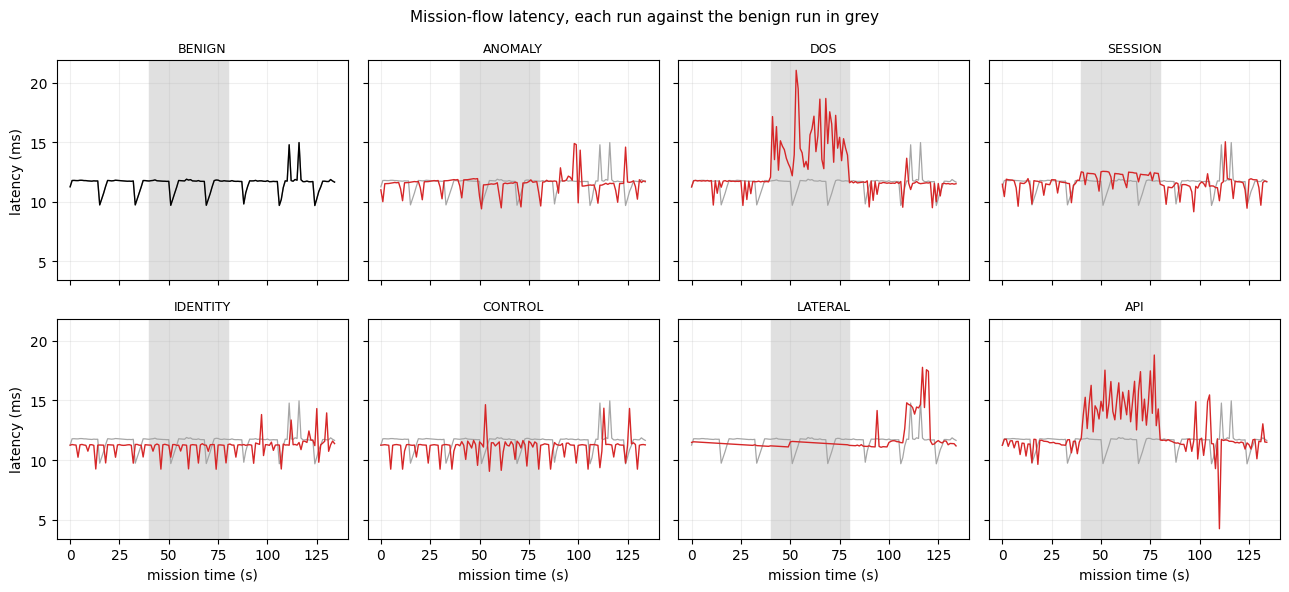

In [11]:
latency = {run: telemetry[run][telemetry[run].session_id.isin(MISSION)]
                .groupby("second").latency_ms.mean() for run in RUNS}
benign_latency = latency[BENIGN]

# One panel per run against the benign run, instead of eight lines on one axis.
figure, axes = plt.subplots(2, 4, figsize=(13, 6), sharex=True, sharey=True)
for panel, run in zip(axes.ravel(), RUNS):
    panel.axvspan(*WINDOW, color="0.88", zorder=0)
    panel.plot(benign_latency.index, benign_latency.values, color="0.65", linewidth=0.9)
    panel.plot(latency[run].index, latency[run].values, linewidth=1,
               color="black" if run == BENIGN else "tab:red")
    panel.set_title(short(run), fontsize=9)
    panel.grid(alpha=0.2)
for panel in axes[:, 0]:
    panel.set_ylabel("latency (ms)")
for panel in axes[1, :]:
    panel.set_xlabel("mission time (s)")
figure.suptitle("Mission-flow latency, each run against the benign run in grey", fontsize=11)
figure.tight_layout()
plt.show()

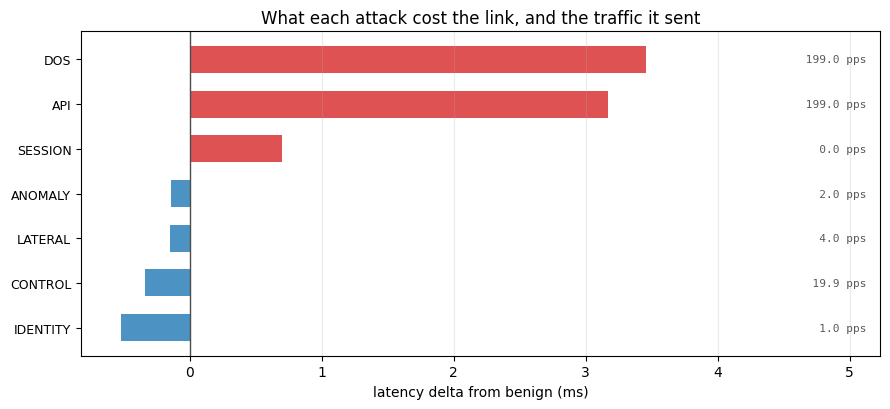

In [12]:
# One row per run, so labels can never collide. The bar is the delay the attack
# caused; the number on the right is the traffic it sent to cause it.
rate = {run: (injected[run].packets_per_second.mean() if len(injected[run]) else 0.0)
        for run in SCENARIOS}
order = sorted(SCENARIOS, key=lambda run: effect[run]["latency_ms"])
position = np.arange(len(order))
delay = [effect[run]["latency_ms"] for run in order]

figure, dose = plt.subplots(figsize=(9, 4.2))
dose.barh(position, delay, 0.6,
          color=["tab:red" if d > 0 else "tab:blue" for d in delay], alpha=0.8)
dose.axvline(0, color="0.3", linewidth=1)
dose.set_yticks(position, [short(run) for run in order], fontsize=9)

edge = max(delay) + (max(delay) - min(delay)) * 0.42
for y, run in zip(position, order):
    dose.text(edge, y, f"{rate[run]:6.1f} pps", fontsize=8, va="center",
              ha="right", family="monospace", color="0.35")
dose.set_xlim(min(delay) - 0.3, edge + 0.1)
dose.grid(alpha=0.25, axis="x")
dose.set(xlabel="latency delta from benign (ms)",
         title="What each attack cost the link, and the traffic it sent")
figure.tight_layout()
plt.show()